# EfficientNetV2 Baseline

## Objective

This notebook establishes the first image-classification baseline for the
brain tumor MRI dataset using EfficientNetV2.

The experiment uses the fixed train, validation, and test partitions generated
in `02_data_preparation.ipynb`. No dataset splitting or case-group
reconstruction is performed in this notebook.

The objectives are to:

- build a reproducible image-loading pipeline from the frozen classification
  manifest;
- apply training-only data augmentation appropriate for brain MRI images;
- train an EfficientNetV2 baseline using transfer learning;
- evaluate performance beyond overall accuracy using class-specific metrics;
- analyze performance across pathology classes and MRI modalities;
- establish a reference baseline for subsequent architecture comparisons.

The test partition will remain untouched during model development and will be
used only for final evaluation.

## 1. Setup and experiment configuration

In [6]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [7]:
IN_COLAB = (
    "COLAB_GPU" in os.environ
    or "COLAB_RELEASE_TAG" in os.environ
)

if IN_COLAB:
    PROJECT_ROOT = Path("/content/brain-tumor-mri")
else:
    PROJECT_ROOT = Path.cwd().parent

MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "classification_manifest.csv"
)

RANDOM_STATE = 42


In [8]:
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
import subprocess
from pathlib import Path

REPO_DIR = Path("/content/brain-tumor-mri")

if not REPO_DIR.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/nouraastafofana-droid/brain-tumor-mri.git",
            str(REPO_DIR),
        ],
        check=True,
    )

print("✓ Repository ready:", REPO_DIR.exists())

✓ Repository ready: True


In [10]:
RAW_DIR = REPO_DIR / "data" / "raw"
PROCESSED_DIR = REPO_DIR / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Data directories ready.")

✓ Data directories ready.


In [11]:
from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("✓ Kaggle authentication ready.")

✓ Kaggle authentication ready.


In [12]:
image_files = list(RAW_DIR.rglob("*.jpg"))

if len(image_files) != 11300:
    !kaggle datasets download \
        -d fernando2rad/brain-tumor-mri-images-30-classes \
        -p /content/brain-tumor-mri/data/raw \
        --unzip

image_files = list(RAW_DIR.rglob("*.jpg"))

print("Images found:", len(image_files))
print("DATA.json exists:", (RAW_DIR / "DATA.json").exists())

Dataset URL: https://www.kaggle.com/datasets/fernando2rad/brain-tumor-mri-images-30-classes
License(s): apache-2.0
100% 478M/478M [00:09<00:00, 53.5MB/s]

Images found: 11300
DATA.json exists: True


In [13]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
from pathlib import Path
import shutil
import pandas as pd

SOURCE_MANIFEST = Path(
    "/content/drive/MyDrive/classification_manifest.csv"
)

TARGET_MANIFEST = Path(
    "/content/brain-tumor-mri/data/processed/classification_manifest.csv"
)

# Recreate data/processed if the Colab runtime was restarted
TARGET_MANIFEST.parent.mkdir(parents=True, exist_ok=True)

print("Source exists:", SOURCE_MANIFEST.exists())
print("Destination folder exists:", TARGET_MANIFEST.parent.exists())

shutil.copy2(SOURCE_MANIFEST, TARGET_MANIFEST)

manifest = pd.read_csv(TARGET_MANIFEST)

print("✓ Manifest copied.")
print("Shape:", manifest.shape)
print()
print(manifest["split"].value_counts())

Source exists: True
Destination folder exists: True
✓ Manifest copied.
Shape: (11300, 12)

split
train         7928
validation    1699
test          1673
Name: count, dtype: int64


In [15]:
manifest = pd.read_csv(MANIFEST_PATH)

print("Shape:", manifest.shape)
print()
print(manifest["split"].value_counts())

manifest.head()

Shape: (11300, 12)

split
train         7928
validation    1699
test          1673
Name: count, dtype: int64


,relative_path,resolved_relative_path,pathology,modality,split_group,split,width,height,point,location,description,pixel_hash
0,Astrocytoma T1C+\T1C+ - Diffuse astrocytoma fr...,data/raw/Astrocytoma T1C+/T1C+ - Diffuse astro...,Astrocytoma,T1C+,9,test,512,512,"{'x': 328, 'y': 150}","['frontal', 'ventricle']","In the left frontal lobe, there´s an intra-axi...",4426b6ab1d355bb7007e793bea34c592437118bff6d766...
1,Astrocytoma T1C+\T1C+ - Diffuse astrocytoma fr...,data/raw/Astrocytoma T1C+/T1C+ - Diffuse astro...,Astrocytoma,T1C+,9,test,512,512,"{'x': 324, 'y': 148}","['frontal', 'ventricle']","In the left frontal lobe, there´s an intra-axi...",bb287c29aa575b46674ccf89141a3a9d0608af47f80bed...
2,Astrocytoma T1C+\T1C+ - Diffuse astrocytoma fr...,data/raw/Astrocytoma T1C+/T1C+ - Diffuse astro...,Astrocytoma,T1C+,9,test,512,512,"{'x': 328, 'y': 142}","['frontal', 'ventricle']","In the left frontal lobe, there´s an intra-axi...",22b7ecd552e34cd825f1a378e6f44fdb6ece3f8301a52c...
3,Astrocytoma T1C+\T1C+ - Diffuse astrocytoma fr...,data/raw/Astrocytoma T1C+/T1C+ - Diffuse astro...,Astrocytoma,T1C+,9,test,512,512,"{'x': 347, 'y': 148}","['frontal', 'ventricle']","In the left frontal lobe, there´s an intra-axi...",d13368e89e8179f39bd06fd5edbabafb3b9e6a4974e0a9...
4,Astrocytoma T1\T1 - Diffuse astrocytoma fronta...,data/raw/Astrocytoma T1/T1 - Diffuse astrocyto...,Astrocytoma,T1,9,test,512,512,"{'x': 318, 'y': 153}","['frontal', 'ventricle']","In the left frontal lobe, there´s an intra-axi...",442dd55ce6e3f167adcf58c8156ebb5045ec12c6d471bb...


In [16]:
manifest["image_path"] = manifest["resolved_relative_path"].apply(
    lambda p: str(PROJECT_ROOT / p)
)

path_check = manifest["image_path"].apply(
    lambda p: Path(p).exists()
)

print("Valid image paths:", path_check.sum())
print("Missing image paths:", (~path_check).sum())

assert path_check.all()

print("✓ All 11,300 model input paths exist.")

Valid image paths: 11300
Missing image paths: 0
✓ All 11,300 model input paths exist.


In [17]:
train_df = manifest[manifest["split"] == "train"].copy()
val_df = manifest[manifest["split"] == "validation"].copy()
test_df = manifest[manifest["split"] == "test"].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 7928
Validation: 1699
Test: 1673


In [18]:
assert len(train_df) == 7928
assert len(val_df) == 1699
assert len(test_df) == 1673

assert set(train_df["split_group"]).isdisjoint(val_df["split_group"])
assert set(train_df["split_group"]).isdisjoint(test_df["split_group"])
assert set(val_df["split_group"]).isdisjoint(test_df["split_group"])

print("✓ Frozen manifest loaded successfully.")
print("✓ Expected train/validation/test sizes recovered.")
print("✓ No split_group crosses model partitions.")

✓ Frozen manifest loaded successfully.
✓ Expected train/validation/test sizes recovered.
✓ No split_group crosses model partitions.


## 2. Model framework and input pipeline

In [19]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = train_df["pathology"].nunique()

CLASS_NAMES = sorted(train_df["pathology"].unique())

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", NUM_CLASSES)
print(CLASS_NAMES)

Image size: 224
Batch size: 32
Classes: 10
['Astrocytoma', 'Ependymoma', 'Glioma', 'Hemangiopericytoma', 'Meningioma', 'Neurocytoma', 'Normal', 'Oligodendroglioma', 'Other', 'Schwannoma']


In [20]:
class_to_index = {
    class_name: idx
    for idx, class_name in enumerate(CLASS_NAMES)
}

index_to_class = {
    idx: class_name
    for class_name, idx in class_to_index.items()
}

train_df["label"] = train_df["pathology"].map(class_to_index)
val_df["label"] = val_df["pathology"].map(class_to_index)
test_df["label"] = test_df["pathology"].map(class_to_index)

train_df[["pathology", "label"]].drop_duplicates().sort_values("label")

,pathology,label
1673,Astrocytoma,0
2455,Ependymoma,1
3180,Glioma,2
4214,Hemangiopericytoma,3
4642,Meningioma,4
6091,Neurocytoma,5
6527,Normal,6
7277,Oligodendroglioma,7
7662,Other,8
8735,Schwannoma,9


In [21]:
for subset in [train_df, val_df, test_df]:
    subset["image_path"] = subset["resolved_relative_path"].apply(
        lambda p: str(PROJECT_ROOT / p)
    )

In [22]:
assert train_df["image_path"].apply(lambda p: Path(p).exists()).all()
assert val_df["image_path"].apply(lambda p: Path(p).exists()).all()
assert test_df["image_path"].apply(lambda p: Path(p).exists()).all()

print("✓ All model input paths exist.")

✓ All model input paths exist.


In [23]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    image = tf.cast(image, tf.float32)

    return image, label

In [24]:
def make_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["image_path"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [26]:
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

In [27]:
images, labels = next(iter(train_ds))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image dtype:", images.dtype)
print(
    "Pixel range:",
    float(tf.reduce_min(images)),
    float(tf.reduce_max(images))
)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Image dtype: <dtype: 'float32'>
Pixel range: 0.0 255.0


## 3. Training data augmentation

Data augmentation is applied only during training.

Because the dataset contains brain MRI images, augmentation is intentionally
conservative. The objective is to improve robustness to small acquisition and
positioning variations without substantially altering anatomical structure.

The baseline uses:

- small rotations;
- small translations;
- mild zoom variations.

Vertical flipping is excluded because it would produce anatomically implausible
orientations. Horizontal flipping is also excluded from the baseline to avoid
introducing unnecessary left-right anatomical transformations.

Validation and test images are never augmented.

In [28]:

data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(
            factor=0.03,
            fill_mode="reflect"
        ),
        layers.RandomTranslation(
            height_factor=0.03,
            width_factor=0.03,
            fill_mode="reflect"
        ),
        layers.RandomZoom(
            height_factor=(-0.05, 0.05),
            width_factor=(-0.05, 0.05),
            fill_mode="reflect"
        ),
    ],
    name="data_augmentation"
)

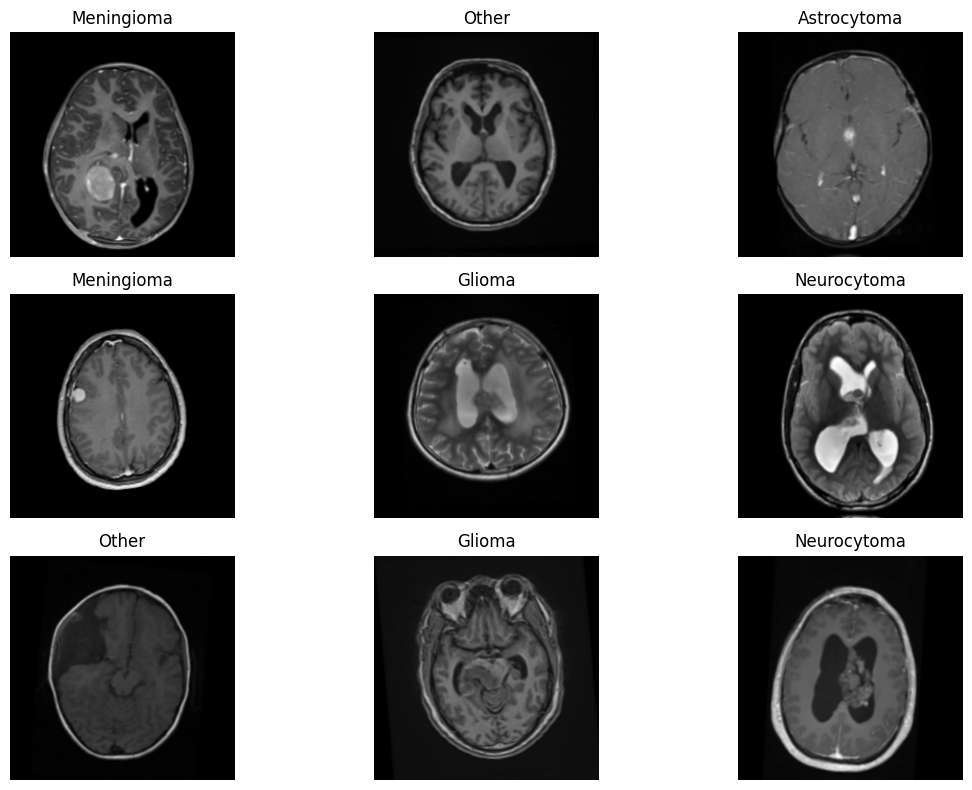

In [29]:
sample_images, sample_labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(9):
    augmented_image = data_augmentation(
        sample_images[i:i+1],
        training=True
    )[0]

    plt.subplot(3, 3, i + 1)
    plt.imshow(
        tf.cast(
            tf.clip_by_value(augmented_image, 0, 255),
            tf.uint8
        )
    )
    plt.title(
        index_to_class[int(sample_labels[i])]
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

### Augmentation validation

Visual inspection confirmed that the selected training augmentations preserve
the overall anatomical structure of the MRI images.

Small rotations, translations, and zoom variations introduce moderate spatial
variability without substantially distorting brain anatomy or removing visible
lesion regions from the field of view.

This conservative augmentation strategy is therefore retained for the
EfficientNetV2 baseline.


## 4. EfficientNetV2B0 baseline architecture

In [30]:
base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_preprocessing=True,
)

base_model.trainable = False

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [38]:
def build_baseline_model():
    base_model = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_preprocessing=True,
    )

    base_model.trainable = False

    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3),
        name="image"
    )

    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)
    x = layers.Dropout(
        0.3,
        name="dropout"
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="classifier"
    )(x)

    model = keras.Model(
        inputs,
        outputs,
        name="efficientnetv2b0_baseline"
    )

    return model, base_model

In [39]:
model, base_model = build_baseline_model()

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print(
    "Trainable parameters:",
    f"{sum(np.prod(v.shape) for v in model.trainable_weights):,}"
)

Trainable parameters: 12,810


## 5. Baseline training

In [40]:
DRIVE_MODEL_DIR = Path(
    "/content/drive/MyDrive/brain-tumor-mri/models"
)

DRIVE_MODEL_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_MODEL_PATH = (
    DRIVE_MODEL_DIR
    / "efficientnetv2b0_baseline.keras"
)

In [41]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=BASELINE_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [42]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.2996 - loss: 1.9550
Epoch 1: val_loss improved from None to 2.05234, saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_baseline.keras
248/248 ━━━━━━━━━━━━━━━━━━━━ 38s 111ms/step - accuracy: 0.3852 - loss: 1.7528 - val_accuracy: 0.3014 - val_loss: 2.0523 - learning_rate: 0.0010
Epoch 2/30
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5018 - loss: 1.4695
Epoch 2: val_loss did not improve from 2.05234
248/248 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - accuracy: 0.5217 - loss: 1.4183 - val_accuracy: 0.2978 - val_loss: 2.1177 - learning_rate: 0.0010
Epoch 3/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5614 - loss: 1.3013
Epoch 3: val_loss did not improve from 2.05234

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
248/248 ━━━━━━━━━━━━━━━━━

### Baseline training outcome

The frozen-backbone EfficientNetV2B0 baseline converged rapidly but showed
clear signs of overfitting.

Training accuracy increased from 38.5% to 62.5% over six epochs, while
validation accuracy remained around 29–30% and validation loss progressively
increased after the first epoch.

The best validation loss was obtained at epoch 1 (`val_loss = 2.0523`), after
which `ReduceLROnPlateau` reduced the learning rate twice and `EarlyStopping`
terminated training at epoch 6.

The model weights were restored to the best epoch.

These results suggest that ImageNet features with a fully frozen backbone are
insufficient for this 10-class MRI classification task and motivate a
fine-tuning stage.

## 6. Fine-tuning EfficientNetV2B0

The frozen-backbone baseline showed limited validation performance and a
rapidly widening train-validation gap.

To adapt the ImageNet-pretrained representation to brain MRI data, the final
layers of the EfficientNetV2B0 backbone are now selectively unfrozen and
fine-tuned using a substantially lower learning rate.

The validation partition remains the only partition used for model selection.
The test partition remains untouched.

In [43]:
baseline_model = keras.models.load_model(
    BASELINE_MODEL_PATH
)

print("Baseline loaded:", BASELINE_MODEL_PATH)

Baseline loaded: /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_baseline.keras


In [44]:
base_model = baseline_model.get_layer(
    "efficientnetv2-b0"
)

print("Backbone:", base_model.name)
print("Backbone layers:", len(base_model.layers))
print("Backbone trainable:", base_model.trainable)

Backbone: efficientnetv2-b0
Backbone layers: 270
Backbone trainable: False


In [45]:
base_model.trainable = True

FINE_TUNE_LAYERS = 30

for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

In [46]:
for layer in base_model.layers[-FINE_TUNE_LAYERS:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [47]:
trainable_backbone_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print(
    "Trainable backbone layers:",
    len(trainable_backbone_layers)
)

print(
    "Last trainable layers:",
    trainable_backbone_layers[-10:]
)

print(
    "Trainable parameters:",
    f"{sum(np.prod(v.shape) for v in baseline_model.trainable_weights):,}"
)

Trainable backbone layers: 24
Last trainable layers: ['block6h_se_squeeze', 'block6h_se_reshape', 'block6h_se_reduce', 'block6h_se_expand', 'block6h_se_excite', 'block6h_project_conv', 'block6h_drop', 'block6h_add', 'top_conv', 'top_activation']
Trainable parameters: 1,166,442


In [48]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

In [49]:
FINETUNED_MODEL_PATH = (
    DRIVE_MODEL_DIR
    / "efficientnetv2b0_finetuned.keras"
)

In [50]:
finetune_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=FINETUNED_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [51]:
finetune_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=finetune_callbacks
)

Epoch 1/20
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5015 - loss: 1.4678
Epoch 1: val_loss improved from None to 2.10129, saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_finetuned.keras
248/248 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.5107 - loss: 1.4467 - val_accuracy: 0.2902 - val_loss: 2.1013 - learning_rate: 1.0000e-05
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5307 - loss: 1.3920
Epoch 2: val_loss did not improve from 2.10129
248/248 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - accuracy: 0.5317 - loss: 1.3929 - val_accuracy: 0.2872 - val_loss: 2.1058 - learning_rate: 1.0000e-05
Epoch 3/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5351 - loss: 1.3773
Epoch 3: val_loss did not improve from 2.10129

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
248/248 ━━━━━━━

### Fine-tuning outcome

Partial fine-tuning of the final EfficientNetV2B0 layers did not improve
validation performance.

The best fine-tuning checkpoint was obtained at epoch 1 with:

- validation accuracy: 29.0%
- validation loss: 2.1013

This is slightly worse than the frozen-backbone baseline, whose best validation
performance reached approximately 30.1% accuracy with a validation loss of
2.0523.

Although training accuracy continued to improve, validation performance remained
flat or degraded, indicating that selectively adapting the final ImageNet
features did not improve generalization on the reconstructed validation groups.

The fine-tuning experiment was therefore stopped early and is not retained as
the best EfficientNetV2B0 configuration.

## 7. Baseline evaluation

In [52]:
history_df = pd.DataFrame(history.history)

history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.385217,1.752778,0.301354,2.052339,0.00100
1,0.521695,1.418285,0.297822,2.117652,0.00100
2,0.558905,1.294974,0.293702,2.091218,0.00100
3,0.607215,1.205666,0.293114,2.135464,0.00050
4,0.618946,1.169807,0.291348,2.157814,0.00050
5,0.624495,1.142654,0.285462,2.160293,0.00025


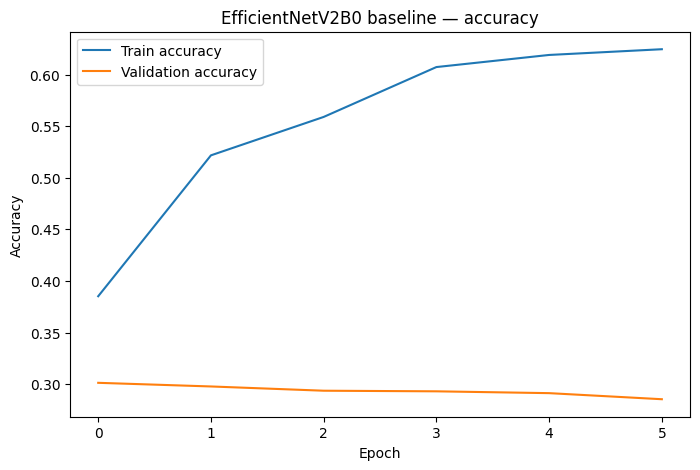

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["accuracy"],
    label="Train accuracy"
)

plt.plot(
    history_df["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetV2B0 baseline — accuracy")
plt.legend()

plt.show()

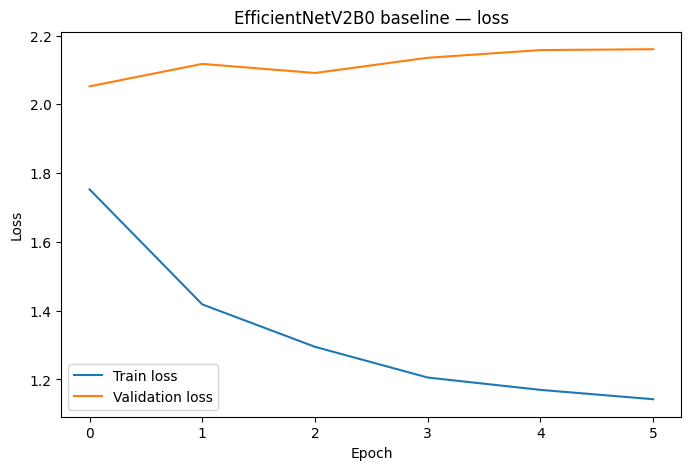

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["loss"],
    label="Train loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetV2B0 baseline — loss")
plt.legend()

plt.show()

In [55]:
best_baseline_model = keras.models.load_model(
    BASELINE_MODEL_PATH
)

print("✓ Best frozen baseline loaded.")

✓ Best frozen baseline loaded.


In [56]:
test_loss, test_accuracy = best_baseline_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.3162 - loss: 2.0322
Test loss: 2.0322
Test accuracy: 0.3162


In [57]:
test_probabilities = best_baseline_model.predict(
    test_ds,
    verbose=1
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

test_labels = test_df["label"].to_numpy()

print("Predictions:", test_predictions.shape)
print("Ground truth:", test_labels.shape)

53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step
Predictions: (1673,)
Ground truth: (1673,)


In [58]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

report = classification_report(
    test_labels,
    test_predictions,
    target_names=CLASS_NAMES,
    digits=3
)

print(report)

                    precision    recall  f1-score   support

       Astrocytoma      0.000     0.000     0.000       168
        Ependymoma      0.169     0.128     0.146       156
            Glioma      0.308     0.163     0.213       221
Hemangiopericytoma      0.200     0.035     0.059        86
        Meningioma      0.329     0.826     0.470       311
       Neurocytoma      0.630     0.341     0.443        85
            Normal      0.448     0.291     0.352       148
 Oligodendroglioma      0.125     0.012     0.022        83
             Other      0.231     0.148     0.180       230
        Schwannoma      0.311     0.573     0.403       185

          accuracy                          0.316      1673
         macro avg      0.275     0.252     0.229      1673
      weighted avg      0.272     0.316     0.256      1673



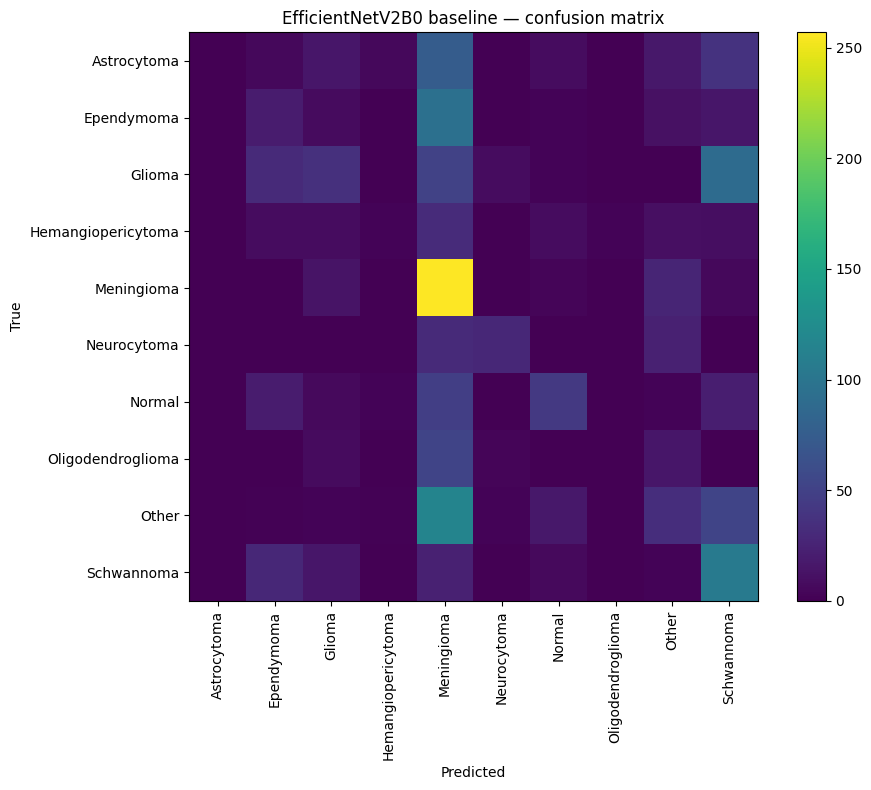

In [59]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=90
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EfficientNetV2B0 baseline — confusion matrix")

plt.colorbar()
plt.tight_layout()

plt.show()

In [60]:
test_results = test_df[
    [
        "pathology",
        "modality",
        "split_group"
    ]
].copy()

test_results["true_label"] = test_labels
test_results["pred_label"] = test_predictions
test_results["correct"] = (
    test_results["true_label"]
    == test_results["pred_label"]
)

In [61]:
modality_performance = (
    test_results
    .groupby("modality")
    .agg(
        n_images=("correct", "size"),
        accuracy=("correct", "mean")
    )
)

modality_performance

,n_images,accuracy
modality,,
T1,593,0.342327
T1C+,632,0.275316
T2,448,0.339286


### EfficientNetV2B0 frozen baseline — conclusions

The frozen EfficientNetV2B0 baseline achieved a test accuracy of 31.6%, with a macro-averaged F1-score of 0.229.

Performance was strongly heterogeneous across pathology classes. Meningioma reached a recall of 82.6%, but its relatively low precision (32.9%) and the confusion matrix indicate substantial overprediction of this class. Schwannoma and Neurocytoma also showed partially discriminative behavior, whereas Astrocytoma, Oligodendroglioma, and Hemangiopericytoma were rarely or never correctly identified.

The large gap between training and validation performance indicates poor generalization to independent reconstructed case groups. Training accuracy increased to 62.4%, while validation accuracy remained around 29–30%, and validation loss failed to improve after the first epoch.

Performance also varied across MRI modalities, with accuracies of 34.2% for T1, 27.5% for T1C+, and 33.9% for T2. However, poor performance was observed across all three modalities, suggesting that the generalization problem is not attributable to a single modality alone.

Partial fine-tuning of the final EfficientNetV2B0 layers did not improve validation performance, indicating that simply adapting the upper backbone layers is insufficient to resolve the observed generalization gap.

These results establish the frozen 224×224 EfficientNetV2B0 model as the reference baseline. The next controlled experiment will evaluate whether increasing the input resolution improves pathology discrimination while keeping the dataset partitions and overall training protocol fixed.

## 8. EfficientNetV2B0 at 300×300

To evaluate whether the 224×224 input resolution limits pathology
discrimination, a second controlled experiment is performed using 300×300
inputs.

All other experimental choices are kept unchanged:

- identical train, validation, and test partitions;
- identical pathology labels;
- identical augmentation strategy;
- identical EfficientNetV2B0 architecture;
- ImageNet initialization;
- frozen backbone during the baseline stage;
- identical optimizer, loss function, and callbacks.

Only the input image resolution is changed from 224×224 to 300×300.

In [62]:
IMG_SIZE_300 = 300

In [63]:
def load_image_300(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(
        image,
        [IMG_SIZE_300, IMG_SIZE_300]
    )
    image = tf.cast(image, tf.float32)

    return image, label

In [64]:
def make_dataset_300(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            dataframe["image_path"].values,
            dataframe["label"].values
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image_300,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [65]:
train_ds_300 = make_dataset_300(
    train_df,
    training=True
)

val_ds_300 = make_dataset_300(
    val_df,
    training=False
)

test_ds_300 = make_dataset_300(
    test_df,
    training=False
)

In [66]:
images_300, labels_300 = next(
    iter(train_ds_300)
)

print("Images shape:", images_300.shape)
print("Labels shape:", labels_300.shape)
print("Pixel range:",
      float(tf.reduce_min(images_300)),
      float(tf.reduce_max(images_300)))

Images shape: (32, 300, 300, 3)
Labels shape: (32,)
Pixel range: 0.0 255.0


In [70]:
data_augmentation_300 = keras.Sequential(
    [
        layers.RandomRotation(
            factor=0.03,
            fill_mode="reflect"
        ),
        layers.RandomTranslation(
            height_factor=0.03,
            width_factor=0.03,
            fill_mode="reflect"
        ),
        layers.RandomZoom(
            height_factor=(-0.05, 0.05),
            width_factor=(-0.05, 0.05),
            fill_mode="reflect"
        ),
    ],
    name="data_augmentation_300"
)

In [72]:
def build_baseline_model_300():
    base_model_300 = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE_300, IMG_SIZE_300, 3),
        include_preprocessing=True,
    )

    base_model_300.trainable = False

    inputs = keras.Input(
        shape=(IMG_SIZE_300, IMG_SIZE_300, 3),
        name="image"
    )

    x = data_augmentation_300(inputs)

    x = base_model_300(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    x = layers.Dropout(
        0.3,
        name="dropout"
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="classifier"
    )(x)

    model_300 = keras.Model(
        inputs,
        outputs,
        name="efficientnetv2b0_300"
    )

    return model_300, base_model_300

In [73]:
model_300, base_model_300 = (
    build_baseline_model_300()
)

In [74]:
model_300.summary()

Model: "efficientnetv2b0_300"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_300           │ (None, 300, 300, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 10, 10, 1280)   │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [75]:
model_300.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

In [76]:
MODEL_300_PATH = (
    DRIVE_MODEL_DIR
    / "efficientnetv2b0_300_baseline.keras"
)

In [77]:
callbacks_300 = [
    keras.callbacks.ModelCheckpoint(
        filepath=MODEL_300_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [78]:
history_300 = model_300.fit(
    train_ds_300,
    validation_data=val_ds_300,
    epochs=30,
    callbacks=callbacks_300
)

Epoch 1/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.2933 - loss: 1.9860
Epoch 1: val_loss improved from None to 2.07626, saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_300_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain-tumor-mri/models/efficientnetv2b0_300_baseline.keras
248/248 ━━━━━━━━━━━━━━━━━━━━ 54s 169ms/step - accuracy: 0.3705 - loss: 1.8025 - val_accuracy: 0.2448 - val_loss: 2.0763 - learning_rate: 0.0010
Epoch 2/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.5016 - loss: 1.4937
Epoch 2: val_loss did not improve from 2.07626
248/248 ━━━━━━━━━━━━━━━━━━━━ 33s 134ms/step - accuracy: 0.5132 - loss: 1.4546 - val_accuracy: 0.2437 - val_loss: 2.0923 - learning_rate: 0.0010
Epoch 3/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5573 - loss: 1.3325
Epoch 3: val_loss did not improve from 2.07626

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
248/248 ━━━━━

### 300×300 resolution experiment — conclusion

Increasing the EfficientNetV2B0 input resolution from 224×224 to 300×300 did
not improve validation performance.

The best 300×300 checkpoint was obtained at epoch 1 with:

- validation accuracy: 24.5%
- validation loss: 2.0763

This underperformed the 224×224 frozen-backbone baseline, which achieved
approximately 30.1% validation accuracy with a validation loss of 2.0523.

Training accuracy continued to increase while validation performance remained
low, indicating that the larger input resolution did not resolve the
generalization gap.

Given that neither partial fine-tuning nor increased input resolution improved
validation performance, the 224×224 frozen EfficientNetV2B0 model is retained
as the reference CNN baseline.